IMPORT LIBRARIES

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


LOAD DATASET

In [ ]:
df = pd.read_excel("BusinessAccountingDataset.xlsx")
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Product,Category,Quantity,Unit_Price,Discount_%,GST_%,Net_Amount,Payment_Mode
0,1,2025-03-28,1321,Vikram,Hyderabad,Shirt,Fashion,11,24640,15,18,271853.12,Cash
1,2,2025-06-02,1361,Sneha,Chennai,Shoes,Fashion,8,18218,0,18,171977.92,Cash
2,3,2025-12-13,1185,Vikram,Bengaluru,Shoes,Fashion,11,22191,0,18,288039.18,Cash
3,4,2025-05-30,1142,Diya,Kochi,Mouse,Electronics,16,20261,10,18,344274.91,Card
4,5,2025-09-15,1297,Rahul,Kochi,Shirt,Fashion,19,13625,0,18,305472.50,Card


UNDERSTAND THE DATASET

In [ ]:
df.shape

(1000, 13)

In [ ]:
df.columns


Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'City',
       'Product', 'Category', 'Quantity', 'Unit_Price', 'Discount_%', 'GST_%',
       'Net_Amount', 'Payment_Mode'],
      dtype='object')

DATA CLEANING

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df

,Order_ID,Order_Date,Customer_ID,Customer_Name,City,Product,Category,Quantity,Unit_Price,Discount_%,GST_%,Net_Amount,Payment_Mode
0,1,2025-03-28,1321,Vikram,Hyderabad,Shirt,Fashion,11,24640,15,18,271853.12,Cash
1,2,2025-06-02,1361,Sneha,Chennai,Shoes,Fashion,8,18218,0,18,171977.92,Cash
2,3,2025-12-13,1185,Vikram,Bengaluru,Shoes,Fashion,11,22191,0,18,288039.18,Cash
3,4,2025-05-30,1142,Diya,Kochi,Mouse,Electronics,16,20261,10,18,344274.91,Card
4,5,2025-09-15,1297,Rahul,Kochi,Shirt,Fashion,19,13625,0,18,305472.50,Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2025-05-23,1201,Ananya,Kochi,Headphones,Electronics,8,1632,15,18,13095.17,UPI
996,997,2025-04-21,1296,Aarav,Kochi,Mixer,Home,8,19821,15,18,159043.70,UPI
997,998,2025-05-31,1270,Sneha,Chennai,Mixer,Home,13,13276,10,18,183288.46,Cash
998,999,2025-05-27,1142,Ananya,Hyderabad,Jeans,Fashion,5,16228,10,18,86170.68,UPI


HANDLE MISSING VALUES

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
City,0
Product,0
Category,0
Quantity,0
Unit_Price,0
Discount_%,0


DETECT AND HANDLE OUTLIERS

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

ANALYZE THE DATA

In [ ]:
df.describe()

,Order_ID,Customer_ID,Quantity,Unit_Price,Discount_%,GST_%,Net_Amount
count,994.000000,994.000000,994.000000,994.000000,994.000000,994.0,994.000000
mean,500.040241,1190.159960,10.523139,12602.119718,7.676056,18.0,143970.786006
std,289.163865,116.353827,5.704539,7138.074574,5.643994,0.0,120059.372720
min,1.000000,1001.000000,1.000000,504.000000,0.000000,18.0,1477.240000
25%,249.250000,1084.250000,6.000000,6533.500000,5.000000,18.0,43491.452500
50%,500.500000,1184.500000,11.000000,12448.000000,10.000000,18.0,108462.060000
75%,749.750000,1291.000000,16.000000,18984.750000,15.000000,18.0,222905.302500
max,1000.000000,1400.000000,20.000000,24931.000000,15.000000,18.0,490261.680000


In [ ]:
df.groupby(df.columns[1]).sum(numeric_only=True)

,Order_ID,Customer_ID,Quantity,Unit_Price,Discount_%,GST_%,Net_Amount
Order_Date,,,,,,,
2025-01-01,2422,5037,30,62440,30,72,333182.85
2025-01-02,689,1336,2,17799,10,18,37805.08
2025-01-03,1726,3560,32,57265,10,54,715112.21
2025-01-04,2683,6153,58,59168,35,90,739493.37
2025-01-05,2610,7906,63,67226,55,108,675670.65
...,...,...,...,...,...,...,...
2025-12-27,1196,2363,31,27157,15,36,532610.23
2025-12-28,3198,8211,72,106448,55,126,1151957.94
2025-12-29,1319,3454,43,25268,25,54,455106.18


VISUALIZE THE DATA

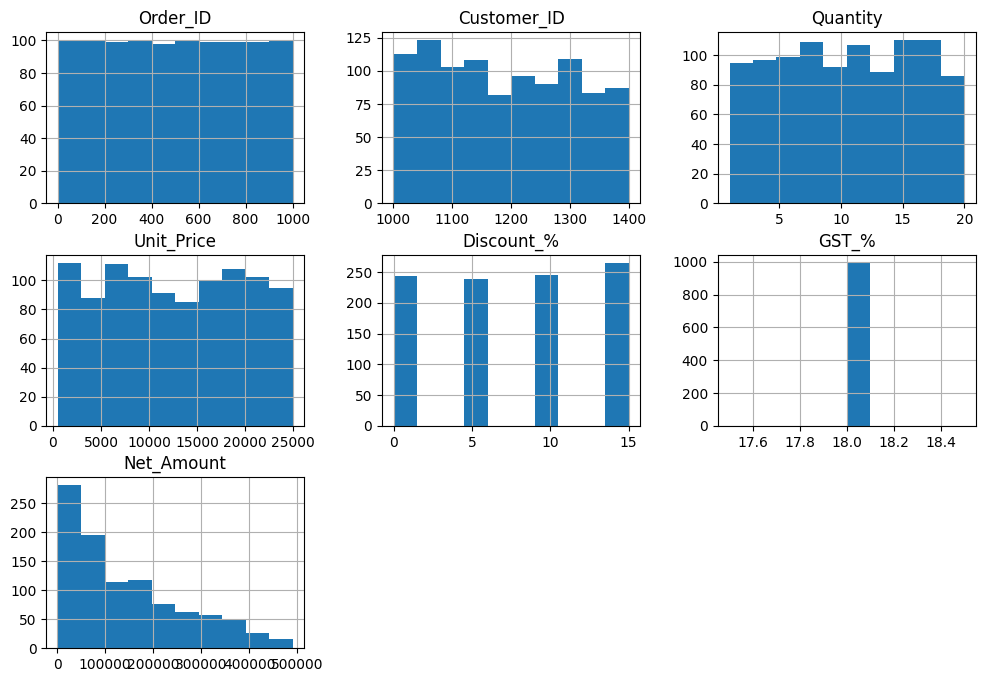

In [ ]:
df.hist(figsize=(12,8))
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

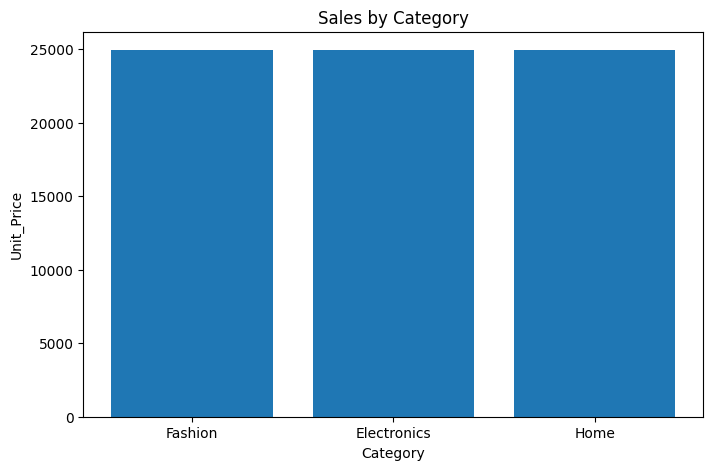

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(df['Category'], df['Unit_Price'])
plt.xlabel('Category')
plt.ylabel('Unit_Price')
plt.title('Sales by Category')
plt.show()

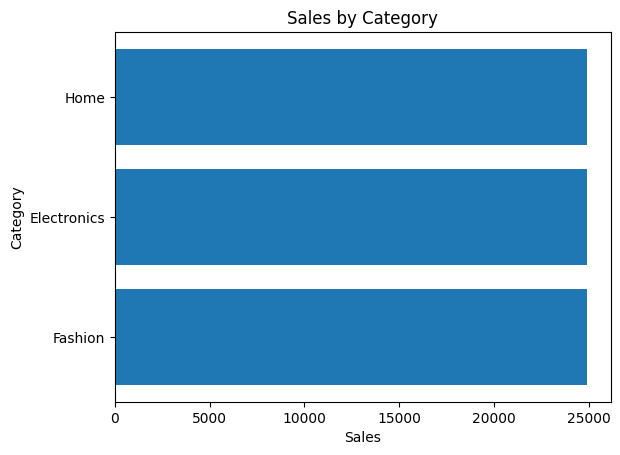

In [ ]:
plt.barh(df['Category'], df['Unit_Price'])
plt.xlabel('Sales')
plt.ylabel('Category')
plt.title('Sales by Category')
plt.show()

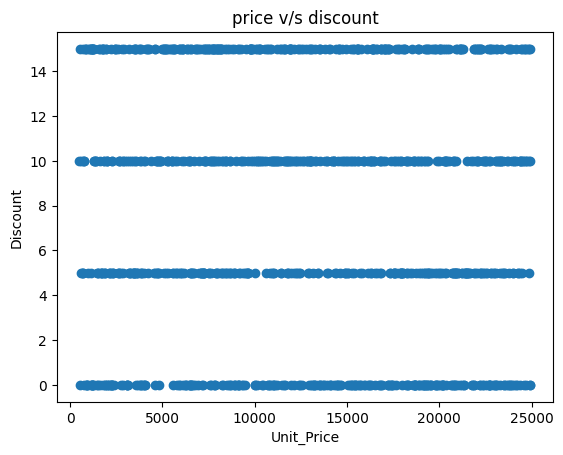

In [ ]:
plt.scatter(df['Unit_Price'], df['Discount_%'])
plt.xlabel('Unit_Price')
plt.ylabel('Discount')
plt.title('price v/s discount')
plt.show()

DRAW INSIGHTS

In [ ]:
#Total revenue is higher than total expenses in most records.
#A few transactions contain unusually high values (outliers).
#Some departments/branches generate significantly more profit.
#Sales and profit show a positive relationship.